# File for generating figures in the manuscript

This Notebook refers to the manuscript `outer-totalistic-network-automata.tex`

In [69]:
from matplotlib import pyplot as plt
import numpy as np
import cellpylib as cpl
import igraph as ig

from matplotlib import rcParams

from tqdm import tqdm

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

from src.analysis import hamming_weight, boolean_sens, mean_field_dens_propagation, derrida_map_analytical
from src.rules import return_life_like_dict, return_equivalent_rule

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Introduction
This part has no figures

### Local update diagram for the Game of Life

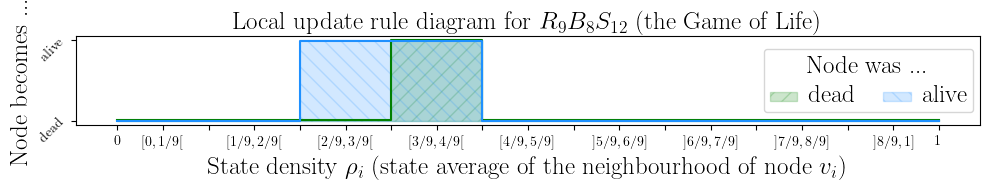

In [3]:
SAVEFIG = False
savename = 'gol_as_llna-diagram.jpg'

# local update rule diagram
def binary_indices(n: int) -> list:
    """
    Returns a list of indices where bits are 1 in the binary representation of n.
    """
    return [i for i, bit in enumerate(bin(n)[:1:-1]) if bit == '1']

resolution = 9

# GoL as LLNA model
beta = 8
sigma = 12
born_if = binary_indices(beta)
survive_if = binary_indices(sigma)
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

# plot both diagrams
fig, ax = plt.subplots(1,1,figsize=(10,2))
model.diagram(ax=ax)

# delete separate ax labels
size=18
ax.set_xlabel(fr'State density $\rho_i$ (state average of the neighbourhood of node $v_i$)', fontsize=size)
ax.set_ylabel(fr'Node becomes ...', fontsize=size)
ax.set_title(fr"Local update rule diagram for {model.__str__(latex=True)} (the Game of Life)", fontsize=size)

legend = ax.legend(ncol=2, loc='center right')
legend.set_title("Node was ...", prop={'size': size})
for text in legend.get_texts():
    text.set_fontsize(size)  # Change legend font size

fig.tight_layout()

if SAVEFIG:
    plt.savefig(f'figures/{savename}', bbox_inches='tight')

### example of isomorphic rules

This is optional (I will probably delete this from the manuscript).

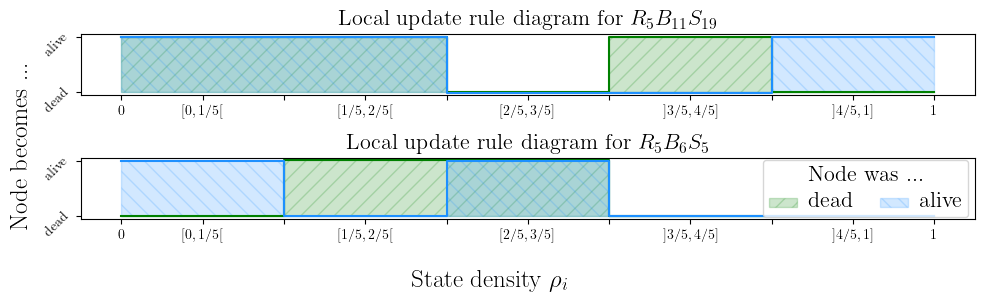

In [4]:
SAVEFIG = False
savename = 'compare-two-iso-rules.jpg'

# local update rule diagram
def binary_indices(n: int) -> list:
    """
    Returns a list of indices where bits are 1 in the binary representation of n.
    """
    return [i for i, bit in enumerate(bin(n)[:1:-1]) if bit == '1']

resolution = 5

# first model
beta = 11
sigma = 19
born_if = binary_indices(beta)
survive_if = binary_indices(sigma)
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

# second model
beta_iso = 2**resolution - 1 - np.sum([2**(resolution-1-i) for i in survive_if])
sigma_iso = 2**resolution - 1 - np.sum([2**(resolution-1-i) for i in born_if])
born_if_iso = binary_indices(beta_iso)
survive_if_iso = binary_indices(sigma_iso)
model_iso = LLNA(resolution, x=born_if_iso, y=survive_if_iso, iso=True)

# plot both diagrams
fig, axs = plt.subplots(2,1,figsize=(10,3))
model.diagram(ax=axs[0])
model_iso.diagram(ax=axs[1])

# delete separate ax labels
axs[0].set_ylabel(None)
axs[1].set_ylabel(None)
axs[0].set_xlabel(None)
axs[1].set_xlabel(None)

# rewrite ax titles
size=16
axs[0].set_title(fr"Local update rule diagram for {model.__str__(latex=True)}", fontsize=size)
axs[1].set_title(fr"Local update rule diagram for {model_iso.__str__(latex=True)}", fontsize=size)

# Change some legend props after the legend is created
axs[0].legend().remove()
legend = axs[1].legend(ncol=2, loc='center right')
legend.set_title("Node was ...", prop={'size': size})
for text in legend.get_texts():
    text.set_fontsize(size)  # Change legend font size

size=18
# fig.suptitle("Local update rule diagrams", fontsize=size)
fig.supxlabel(fr'State density $\rho_i$', fontsize=size)
fig.supylabel(fr'Node becomes ...', fontsize=size)

fig.tight_layout()

if SAVEFIG:
    plt.savefig(f'figures/{savename}', bbox_inches='tight')

# Genotype parameters

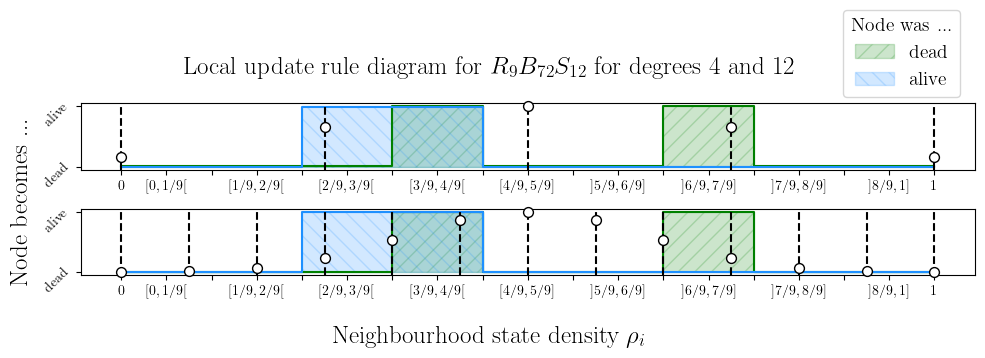

In [ ]:
SAVEFIG = False
savename_prefix = f'compare-two-degrees_diagram_'

resolution = 9
degree0 = 4
degree1 = 12

# model
beta = 72
sigma = 12
born_if = binary_indices(beta)
survive_if = binary_indices(sigma)
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)
savename = savename_prefix + f'{model.__str__()}.jpg'

# plot both diagrams
fig, axs = plt.subplots(2,1,figsize=(10,3))
model.diagram(ax=axs[0], degree=degree0, plot_dist=True)
model.diagram(ax=axs[1], degree=degree1, plot_dist=True)

# delete separate ax labels
axs[0].set_ylabel(None)
axs[1].set_ylabel(None)
axs[0].set_xlabel(None)
axs[1].set_xlabel(None)

# rewrite ax titles
size=16
axs[0].set_title(None)
axs[1].set_title(None)
# axs[0].set_title(fr"Local update rule diagram for {model.__str__(latex=True)} for degree {degree0}", fontsize=size)
# axs[1].set_title(fr"Local update rule diagram for {model.__str__(latex=True)} for degree {degree1}", fontsize=size)

# Change some legend props after the legend is created
axs[0].legend().remove()
axs[1].legend().remove()
# legend = axs[0].legend(ncol=2, loc='upper center', bbox_to_anchor=(.9, 1.2))
# legend.set_title("Node was ...", prop={'size': size})
# for text in legend.get_texts():
    # text.set_fontsize(size)  # Change legend font size

# Create a custom legend for the entire figure
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=1, loc='upper right', bbox_to_anchor=(.98, 1.17), fontsize=size-2, title="Node was ...", title_fontsize=size-2)

size=18
fig.suptitle(fr"Local update rule diagram for {model.__str__(latex=True)} for degrees {degree0} and {degree1}", fontsize=size)
fig.supxlabel(fr'Neighbourhood state density $\rho_i$', fontsize=size)
fig.supylabel(fr'Node becomes ...', fontsize=size)

fig.tight_layout()

if SAVEFIG:
    plt.savefig(f'figures/{savename}', bbox_inches='tight')

## Hamming weight and mean-field theory

100%|██████████| 19/19 [00:00<00:00, 671.97it/s]


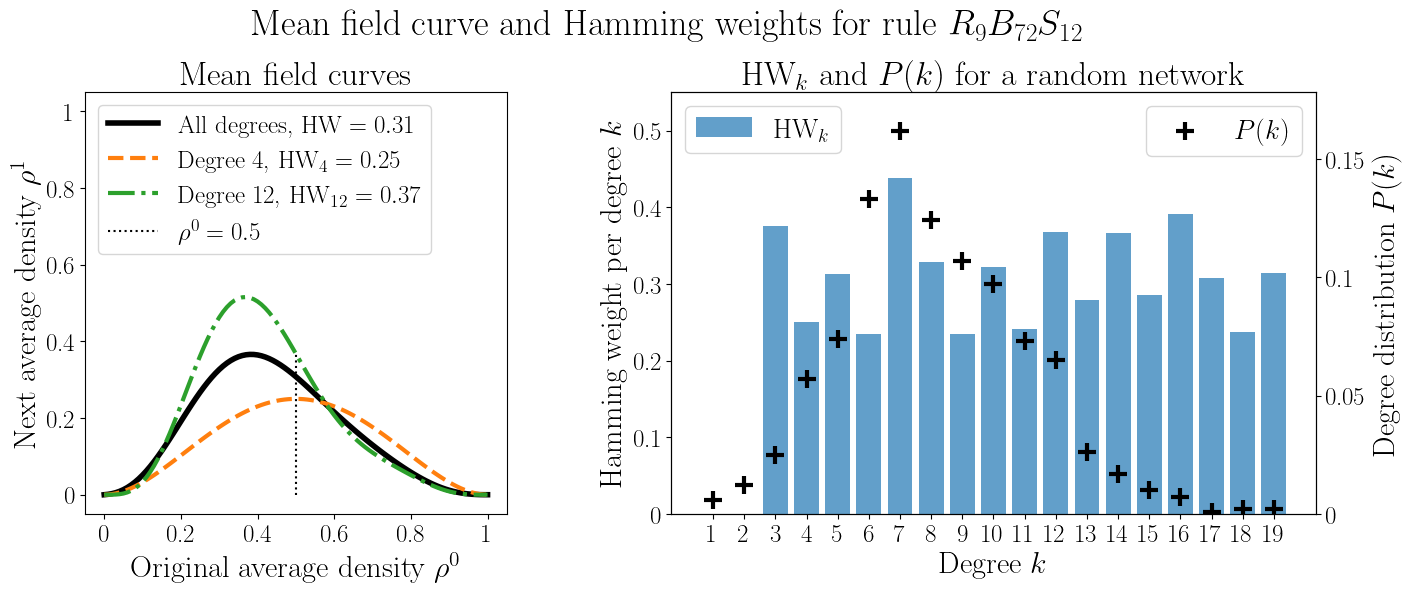

In [38]:
SAVEFIG = False

# create the model
life_like_dict = return_life_like_dict()
life_like_name = "highlife" # i like: replicator, diamoeba, 34_life, 2x2 (looks like a python that swallowed an elephant)
beta, sigma = life_like_dict[life_like_name]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

# create the graph
num_nodes = 1000
avg_degree = 8
# Probability for edge creation
p = avg_degree / (num_nodes - 1)
# Generate a connected random graph using the Erdos-Renyi model
random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, p=p)
while not random_graph.is_connected():
    random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, p=p)
degree_per_node = random_graph.degree()
degree_counts = np.bincount(degree_per_node)[1:] # skip first, because by design there is no degree=0
degree_distribution = degree_counts / np.sum(degree_counts)
degrees = np.arange(1, max(degree_per_node)+1)

# this is some kind of Fourier transformation! Showing the elements that make up the total wave
resolution = 9
model = LLNA(resolution, B_set, S_set, iso=True)
B_set, S_set = model.rule
degrees_to_plot = np.array([4, 12])
ls_list = ['--', '-.']
default_colors = np.array((plt.rcParams['axes.prop_cycle'].by_key()['color']))
color_list = default_colors[1:3]

# mean field curve and HW values
num_dens_points = 101
current_dens = np.linspace(0,1,num_dens_points)
next_dens_list = []
HW_list = []
for degree in tqdm(degrees, total=len(degrees)):
    # mean field curve
    next_dens = mean_field_dens_propagation(resolution, B_set, S_set, current_dens, degree)
    next_dens_list.append(next_dens)
    # Hamming weight
    HW = hamming_weight(resolution, B_set, S_set, degree)
    HW_list.append(HW)
next_dens_array = np.array(next_dens_list)
# take weighted average
next_dens_average = np.sum(degree_counts[:,np.newaxis]/num_nodes*next_dens_array, axis=0)
HW_array = np.array(HW_list)
HW_average = np.sum(np.array(degree_distribution) * np.array(HW_array))

# add for completeness
LHS = int(0 in B_set)
RHS = int(resolution-1 in S_set)

# create figure
fig, axs = plt.subplots(1,2,figsize=(15,6))

next_dens_array_to_plot = next_dens_array[degrees_to_plot-1]
HW_array_to_plot = HW_array[degrees_to_plot-1]
# plot average
axs[0].plot(current_dens, next_dens_average, label=f'All degrees, $\\text{{HW}} = {round(HW_average,2)}$', ls='-', color='black', lw=4)
for next_dens, degree, HW, ls, color in zip(next_dens_array_to_plot, degrees_to_plot, HW_array_to_plot, ls_list, color_list):
    axs[0].plot(current_dens, next_dens, label=f'Degree {degree}, $\\text{{HW}}_{{{degree}}} = {round(HW,2)}$', ls=ls, color=color, lw=3)
    # plt.scatter(0.5, HW, color='black', s=100, marker='*')
# ax.plot(current_dens, next_dens_average, color='black', label="Average", lw=4, ls='-.')
# plt.plot([0,1], [0,1], 'k--')
# ax.plot([0, .5], [HW_average, HW_average], 'k--', label="Average Hamming weight")
# ax.scatter(0, LHS, color='black', s=100, marker='x')
# ax.scatter(1, RHS, color='black', s=100, marker='x')
# plot indicator for HW
axs[0].plot([.5,.5], [0,np.max(np.append(HW_array_to_plot,HW_average))], 'k:', label=f"$\\rho^0=0.5$")
# axs[0].plot([0, .5], [HW_average, HW_average], 'k:')

fontsize=22

# plot mean field curves
axs[0].legend(fontsize=fontsize-4, loc='upper left')
axs[0].set_xlabel("Original average density $\\rho^0$", fontsize=fontsize)
axs[0].set_ylabel("Next average density $\\rho^1$", fontsize=fontsize)
axs[0].set_xlim([-0.05, 1.05])
axs[0].set_ylim([-0.05, 1.05])
ticklabels = [0, .2, .4, .6, .8, 1]
axs[0].set_xticks(ticklabels)
axs[0].set_yticks(ticklabels)
axs[0].set_xticklabels(ticklabels, size=fontsize-4)
axs[0].set_yticklabels(ticklabels, size=fontsize-4)
axs[0].set_title(f"Mean field curves", size=fontsize+2)
axs[0].set_aspect(1)

# Hamming weights on a random graph
# find degree distribution
ax_rhs = axs[1].twinx()
ax_rhs.scatter(degrees, degree_distribution, color='black', s=150, marker='+', label="$P(k)$", zorder=10, linewidths=3)

# calculate the hamming weights for all degree
HW_list = [hamming_weight(resolution, B_set, S_set, d, norm=True) for d in degrees]
axs[1].bar(degrees, HW_list, alpha=0.7, label="$\\text{{HW}}_k$")

# plot documentation
axs[1].set_xticks(degrees)
axs[1].set_xticklabels(degrees)
# axs[1].set_title(f"$\\text{{HW}}_k$ and $P(k)$ for a random network ($N={num_nodes}$, $\\langle k\\rangle = {avg_degree}$)", fontsize=fontsize+2)
axs[1].set_title(f"$\\text{{HW}}_k$ and $P(k)$ for a random network", fontsize=fontsize+2)
axs[1].legend(loc='upper left', fontsize=fontsize-2)
axs[1].set_ylabel("Hamming weight per degree $k$", fontsize=fontsize)
yticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
axs[1].set_ylim([0, yticks[-1]*1.1])
axs[1].set_yticks(yticks)
axs[1].set_yticklabels(yticks, fontsize=fontsize-4)
axs[1].set_xlabel("Degree $k$", fontsize=fontsize)
axs[1].set_xticks(degrees)
axs[1].set_xticklabels(degrees, fontsize=fontsize-4)

ax_rhs.legend(fontsize=fontsize-2, loc='upper right')
ax_rhs.set_ylabel("Degree distribution $P(k)$", fontsize=fontsize)
ax_rhs.set_ylim([0, max(degree_distribution)*1.1])
yticks = [0, 0.05, 0.10, 0.15]
ax_rhs.set_yticks(yticks)
ax_rhs.set_yticklabels(yticks, fontsize=fontsize-4)

fig.suptitle(f"Mean field curve and Hamming weights for rule {model.__str__(latex=True)}", fontsize=fontsize+4)

fig.tight_layout()

savename = f"mean_field_curve-HW_distribution-{model.__str__()}.pdf"
if SAVEFIG:
    plt.savefig(f'figures/{savename}', bbox_inches='tight')

## Boolean sensitivity and the Derrida plot

100%|██████████| 19/19 [00:23<00:00,  1.25s/it]


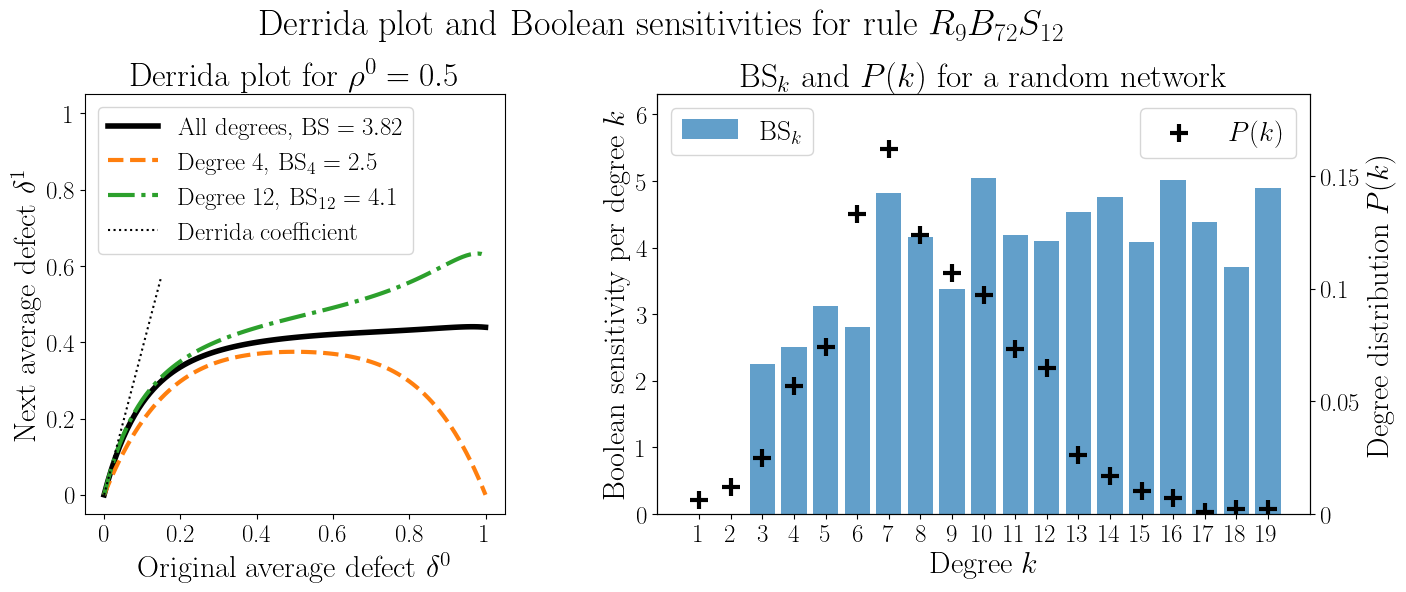

In [39]:
SAVEFIG = False

# create the model
life_like_dict = return_life_like_dict()
life_like_name = "highlife" # i like: replicator, diamoeba, 34_life, 2x2
beta, sigma = life_like_dict[life_like_name]
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

NEW_GRAPH = False

if NEW_GRAPH:
    # create the graph
    num_nodes = 1000
    avg_degree = 8
    # Probability for edge creation
    p = avg_degree / (num_nodes - 1)
    # Generate a connected random graph using the Erdos-Renyi model
    random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, p=p)
    while not random_graph.is_connected():
        random_graph = ig.Graph.Erdos_Renyi(n=num_nodes, p=p)
    degree_per_node = random_graph.degree()
    degree_counts = np.bincount(degree_per_node)[1:] # skip first, because by design there is no degree=0
    degree_distribution = degree_counts / np.sum(degree_counts)
    degrees = np.arange(1, max(degree_per_node)+1)

# this is some kind of Fourier transformation!
resolution = 9
model = LLNA(resolution, B_set, S_set, iso=True)
B_set, S_set = model.rule

degrees_to_plot = np.array([4, 12])
ls_list = ['--', '-.']
default_colors = np.array((plt.rcParams['axes.prop_cycle'].by_key()['color']))
color_list = default_colors[1:3]

# Derrida plot and Boolean sensitivity
init_config_dens = 0.5
num_delta_points = 101
current_deltas = np.linspace(0, 1, num_delta_points)
next_deltas_list = []
BS_list = []
for degree in tqdm(degrees, total=len(degrees)):
    # Derrida plot
    next_deltas = derrida_map_analytical(resolution, B_set, S_set, current_deltas, degree, init_config_dens=init_config_dens)
    next_deltas_list.append(next_deltas)
    # Boolean sensitivity
    BS = boolean_sens(resolution, B_set, S_set, degree, norm_degree=False)
    BS_list.append(BS)
next_deltas_array = np.array(next_deltas_list)
# take weighted average
next_deltas_average = np.sum(degree_counts[:,np.newaxis]/num_nodes*next_deltas_array, axis=0)
BS_array = np.array(BS_list)
BS_average = np.sum(np.array(degree_distribution) * np.array(BS_array))

# create figure
fig, axs = plt.subplots(1,2,figsize=(15,6))
fontsize=22

next_deltas_array_to_plot = next_deltas_array[degrees_to_plot-1]
BS_array_to_plot = BS_array[degrees_to_plot-1]
# plot average
axs[0].plot(current_deltas, next_deltas_average, label=f'All degrees, $\\text{{BS}} = {round(BS_average,2)}$', ls='-', color='black', lw=4)
for next_deltas, degree, BS, ls, color in zip(next_deltas_array_to_plot, degrees_to_plot, BS_array_to_plot, ls_list, color_list):
    axs[0].plot(current_deltas, next_deltas, label=f'Degree {degree}, $\\text{{BS}}_{{{degree}}} = {round(BS,2)}$', ls=ls, color=color, lw=3)
# add BS as slope
DC_factor = 0.15
axs[0].plot(np.array([0, 1])*DC_factor, np.array([0, BS_average])*DC_factor, 'k:', label='Derrida coefficient')

# plot Derrida plot
axs[0].legend(fontsize=fontsize-4, loc='upper left')
axs[0].set_xlabel("Original average defect $\\delta^0$", fontsize=fontsize)
axs[0].set_ylabel("Next average defect $\\delta^1$", fontsize=fontsize)
axs[0].set_xlim([-0.05, 1.05])
axs[0].set_ylim([-0.05, 1.05])
ticklabels = [0, .2, .4, .6, .8, 1]
axs[0].set_xticks(ticklabels)
axs[0].set_yticks(ticklabels)
axs[0].set_xticklabels(ticklabels, size=fontsize-4)
axs[0].set_yticklabels(ticklabels, size=fontsize-4)
axs[0].set_title(f"Derrida plot for $\\rho^0={round(init_config_dens,2)}$", size=fontsize+2)
axs[0].set_aspect(1)

# Boolean sensitivites on a random graph
# find degree distribution
ax_rhs = axs[1].twinx()
ax_rhs.scatter(degrees, degree_distribution, color='black', s=150, marker='+', label="$P(k)$", zorder=10, linewidths=3)

# calculate the hamming weights for all degrees
# HW_list = [hamming_weight(resolution, B_set, S_set, d) for d in degrees]
axs[1].bar(degrees, BS_array, alpha=0.7, label="$\\text{{BS}}_k$")

# plot documentation
axs[1].set_xticks(degrees)
axs[1].set_xticklabels(degrees)
# axs[1].set_title(f"$\\text{{HW}}_k$ and $P(k)$ for a random network ($N={num_nodes}$, $\\langle k\\rangle = {avg_degree}$)", fontsize=fontsize+2)
axs[1].set_title(f"$\\text{{BS}}_k$ and $P(k)$ for a random network", fontsize=fontsize+2)
axs[1].legend(loc='upper left', fontsize=fontsize-2)
axs[1].set_ylabel("Boolean sensitivity per degree $k$", fontsize=fontsize)
yticks = [0, 1, 2, 3, 4, 5, 6]
axs[1].set_ylim([0, yticks[-1]*1.05])
axs[1].set_yticks(yticks)
axs[1].set_yticklabels(yticks, fontsize=fontsize-4)
axs[1].set_xlabel("Degree $k$", fontsize=fontsize)
axs[1].set_xticks(degrees)
axs[1].set_xticklabels(degrees, fontsize=fontsize-4)

ax_rhs.legend(fontsize=fontsize-2, loc='upper right')
ax_rhs.set_ylabel("Degree distribution $P(k)$", fontsize=fontsize)
ax_rhs.set_ylim([0, max(degree_distribution)*1.15])
yticks = [0, 0.05, 0.10, 0.15]
ax_rhs.set_yticks(yticks)
ax_rhs.set_yticklabels(yticks, fontsize=fontsize-4)

fig.suptitle(f"Derrida plot and Boolean sensitivities for rule {model.__str__(latex=True)}", fontsize=fontsize+4)

fig.tight_layout()

savename = f"derrida_plot-BS_distribution-{model.__str__()}.pdf"
if SAVEFIG:
    plt.savefig(f'figures/{savename}', bbox_inches='tight')

Something is wrong with the definition of the Boolean sensitivity. It has to do with the normalisation, I think. The Derrida plot seems to be alright, cause it clearly follows the data. The BS should be linear to the Derrida coefficient, though, and that currently isn't the case, as can be seen in the LHS plot.

## Correlation Hamming weight and Boolean sensitivity

In [9]:
# let's compare the sensitivity with the Hamming weight for all NAs

resolution = 5
degree_rules = 3

sigmas=range(2**resolution)
betas=range(2**resolution)

HWs_rules = []
BSs_rules = []
equiv_rule_list = []
for beta in tqdm(betas, total=len(betas)):
    born_if = binary_indices(beta)
    for sigma in sigmas:
        if (beta, sigma) not in equiv_rule_list:
            survive_if = binary_indices(sigma)
            HW = hamming_weight(resolution, born_if, survive_if, degree_rules, norm=True, iso=True)
            BS = boolean_sens(resolution, born_if, survive_if, degree_rules, norm_degree=False, iso=True)
            HWs_rules.append(HW)
            BSs_rules.append(BS)
            # add the equivalent rule to the list
            beta_equiv, sigma_equiv = return_equivalent_rule(resolution, born_if, survive_if, return_decimals=True)
            equiv_rule_list.append((beta_equiv, sigma_equiv))

100%|██████████| 32/32 [00:00<00:00, 37.89it/s]


In [76]:
# let's compare the sensitivity with the Hamming weight for all non-equivalent NAs

resolution = 5

beta=6
sigma=11
max_degree = 250

born_if = binary_indices(beta)
survive_if = binary_indices(sigma)
model_degrees = LLNA(resolution, x=born_if, y=survive_if, iso=True)

HWs_degrees = []
BSs_degrees = []
for degree in range(1,max_degree+1):
    HW = hamming_weight(resolution, born_if, survive_if, degree, norm=True, iso=True)
    BS = boolean_sens(resolution, born_if, survive_if, degree, norm_degree=False, iso=True)
    HWs_degrees.append(HW)
    BSs_degrees.append(BS)

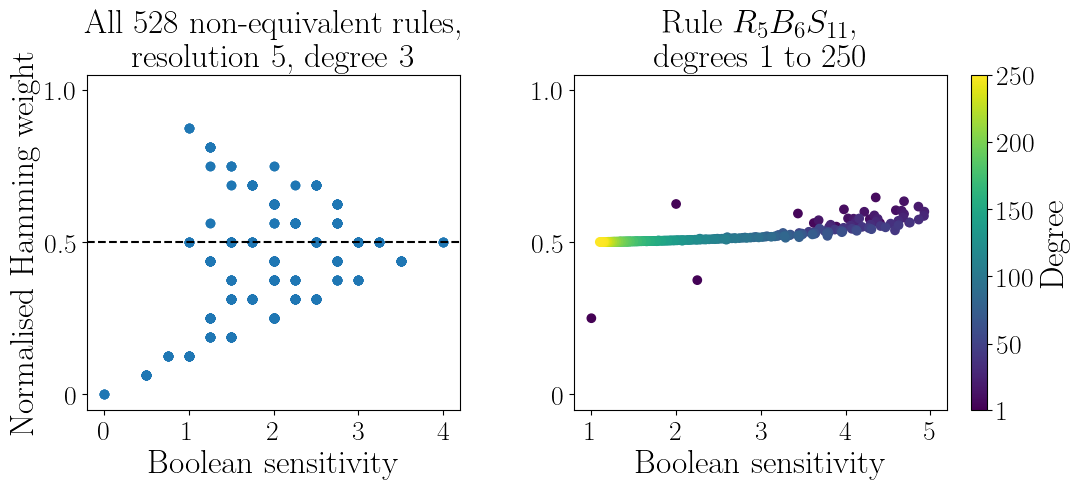

In [100]:
SAVEFIG = False
savename=f'correlation-HW-BS_{model_degrees.__str__()}.pdf'

fig, axs = plt.subplots(1,3,figsize=(11,5), width_ratios=[1,0.001,1.25])
fontsize=24

axs[0].scatter(BSs_rules, HWs_rules)
axs[0].set_title(f"All 528 non-equivalent rules,\nresolution {resolution}, degree {degree_rules}", fontsize=fontsize)
axs[0].axhline(.5, color='black', linestyle='--')
xticks = [0, 1, 2, 3, 4]
axs[0].set_xticks(xticks)
axs[0].set_xticklabels(xticks, fontsize=fontsize-4)
axs[0].set_xlim([-0.2, 4.2])

axs[1].axis('off')

sc = axs[2].scatter(BSs_degrees, HWs_degrees, c=range(1, max_degree+1), cmap='viridis')
axs[2].set_title(f"Rule {model_degrees.__str__(latex=True)},\ndegrees $1$ to ${max_degree}$", fontsize=fontsize)
xticks = [1, 2, 3, 4, 5]
axs[2].set_xticks(xticks)
axs[2].set_xticklabels(xticks, fontsize=fontsize-4)
axs[2].set_xlim([0.8, 5.2])

# Add colorbar linked to the scatter plot
cbar = fig.colorbar(sc, ax=axs[2], ticks=[1, 50, 100, 150, 200, 250])
cbar.set_label("Degree", fontsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize-4)

for ax in axs:
    ax.set_xlabel("Boolean sensitivity", fontsize=fontsize)
    if ax == axs[0]:
        ax.set_ylabel("Normalised Hamming weight", fontsize=fontsize)
    # ax.set_xlim([-0.05,1.05])
    yticks = [0, 0.5, 1.]
    # ax.set_xticks(xticks)
    # ax.set_xticklabels(xticks, fontsize=fontsize-4)
    ax.set_ylim([-0.05, 1.05])
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticks, fontsize=fontsize-4)
    # ax.set_aspect(1.0)

# plt.subplots_adjust(wspace=0.1)
fig.tight_layout()

if SAVEFIG:
    plt.savefig(f'figures/{savename}', bbox_inches='tight')


### Boolean sensitivity and Hamming weight histograms for various networks types

# Phenotype parameters